<a href="https://colab.research.google.com/github/Hitorido/Machine-Learning-Activity/blob/main/Data_Analytics_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [48]:
iris = load_iris()
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [49]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [50]:
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
    )
df["species"] = iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [51]:
print('number pf rpws: ', df.shape[0])
print('number of columns', df.shape[1])

number pf rpws:  150
number of columns 5


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [53]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [54]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [55]:
print(df['species'].unique())

['setosa' 'versicolor' 'virginica']


In [56]:
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


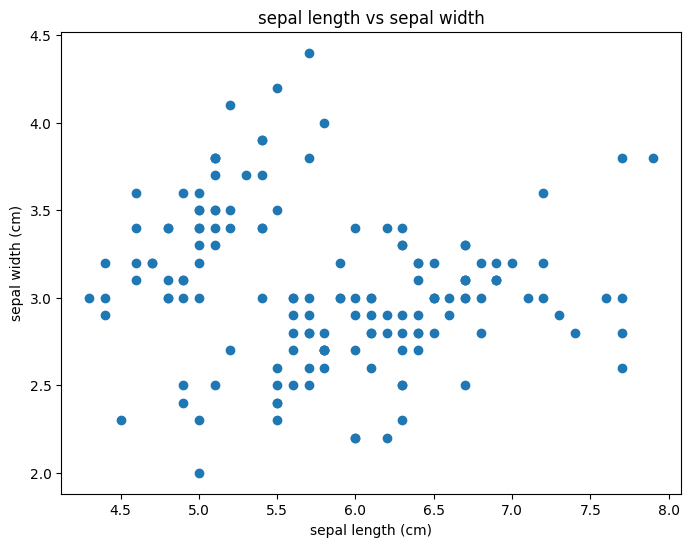

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
)

plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title('sepal length vs sepal width')
plt.show()

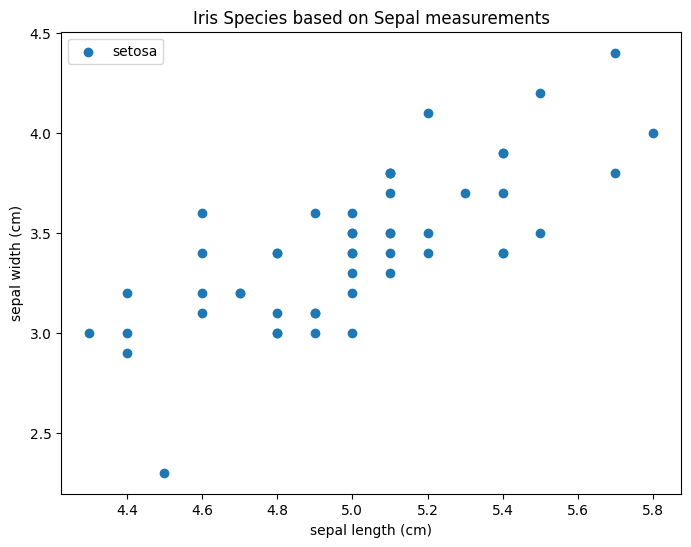

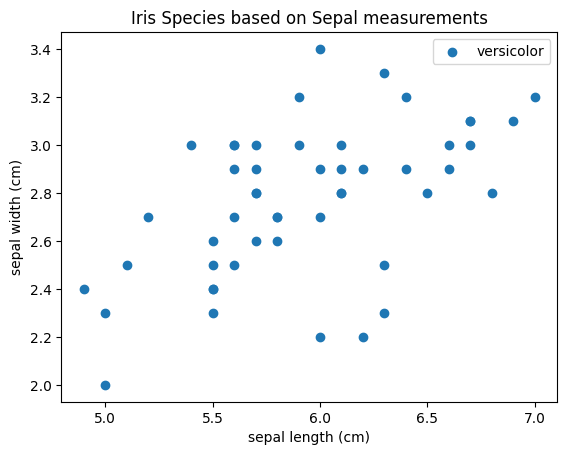

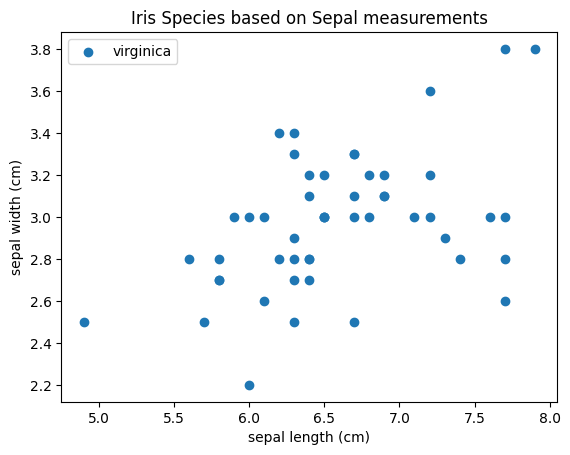

In [58]:
plt.figure(figsize=(8,6))

for species in df['species'].unique():

  subset = df[df['species']==species]

  plt.scatter(
      subset['sepal length (cm)'],
      subset['sepal width (cm)'],
      label=species
  )

  plt.xlabel('sepal length (cm)')
  plt.ylabel('sepal width (cm)')
  plt.title('Iris Species based on Sepal measurements')
  plt.legend()
  plt.show()

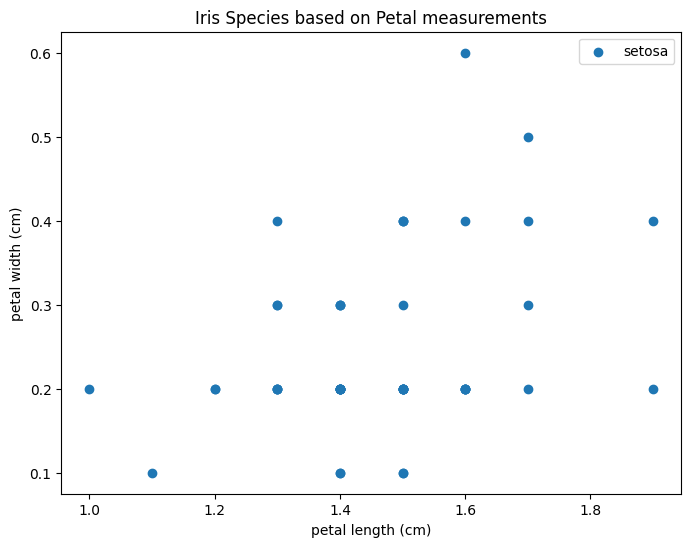

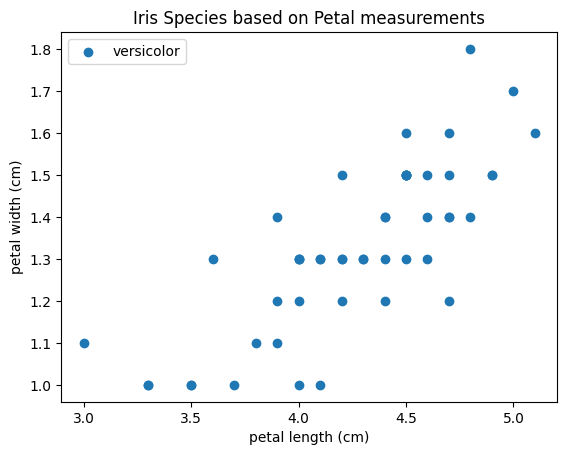

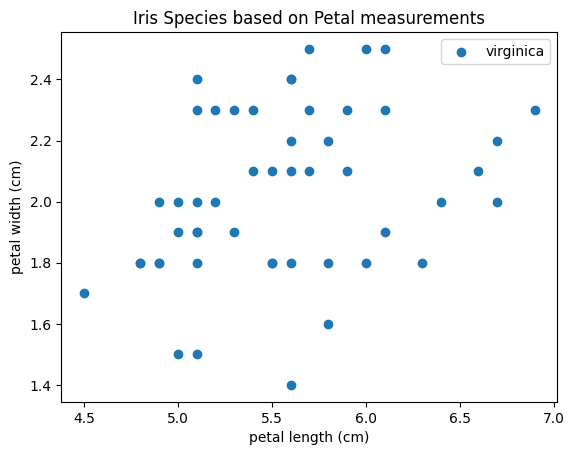

In [59]:
plt.figure(figsize=(8,6))

for species in df['species'].unique():

  subset = df[df['species']==species]

  plt.scatter(
      subset['petal length (cm)'],
      subset['petal width (cm)'],
      label=species
  )

  plt.xlabel('petal length (cm)')
  plt.ylabel('petal width (cm)')
  plt.title('Iris Species based on Petal measurements')
  plt.legend()
  plt.show()

In [60]:
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('training observations: ', len(x_train))
print('testing observations: ', len(x_test))

training observations:  120
testing observations:  30


In [61]:
model = KNeighborsClassifier(n_neighbors=3)

In [62]:
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [63]:
y_prod = model.predict(x_test)
print(y_prod)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [64]:
print('actual: ')
print(y_test)

print('\nPredicted: ')
print(y_prod)

actual: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted: 
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [65]:
accuracy = accuracy_score(y_test, y_prod)
print('accuracy: ', accuracy)

accuracy:  1.0


In [66]:
new_flower = [[4.9, 3, 1.4, 0.2]]

In [67]:


prediction = model.predict(new_flower)
print(
    "predicted species: ",
    iris.target_names[model.predict(new_flower)[0]]
)

predicted species:  setosa


In [68]:
probabilities = model.predict_proba(new_flower)
print(probabilities)

[[1. 0. 0.]]


In [69]:
for species, probability in zip(
    iris.target_names,
    probabilities[0]
    ):

  print(f'{species}: {probability * 100:.2f}%')

setosa: 100.00%
versicolor: 0.00%
virginica: 0.00%


In [70]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(f"K={k}, Accuracy = {accuracy:2f}")

K=1, Accuracy = 0.966667
K=3, Accuracy = 1.000000
K=5, Accuracy = 1.000000
K=7, Accuracy = 0.966667
K=9, Accuracy = 1.000000


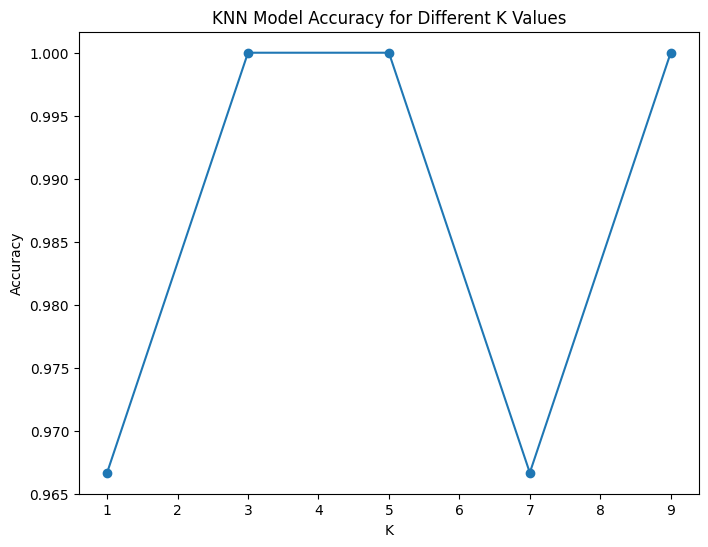

In [71]:
plt.figure(figsize=(8,6))
plt.plot(
    k_values,
    accuracies,
    marker='o'
    )

plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Model Accuracy for Different K Values')
plt.xticks
plt.show()

In [72]:
results = pd.DataFrame({
    'actual': iris.target_names[y_test],
    'predicted': iris.target_names[y_prod]
})

results.head(10)

,actual,predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [73]:
results['correct'] = (
    results["actual"] == results["predicted"]
)
results.head(10)

,actual,predicted,correct
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


#Machine Learn for Students Performance